### Use significant genes from NSC clustering (at 1.0 threshold) in a network analysis (WGCN & PPI)

In [6]:
import pandas as pd
nsc_genes = pd.read_csv('data/nsc_genes_t1_0.csv')
nsc_freq1 = nsc_genes[nsc_genes['selection_frequency'] == 1.0]
nsc_freq1

,gene_id,selection_frequency
20,ENSG00000002549,1.0
95,ENSG00000005471,1.0
96,ENSG00000005483,1.0
99,ENSG00000005700,1.0
206,ENSG00000008294,1.0
...,...,...
18495,ENSG00000276234,1.0
18498,ENSG00000276368,1.0
18597,ENSG00000281131,1.0
18641,ENSG00000283701,1.0


In [2]:
nsc_freq1["gene_id"].nunique()

392

### EDA with the whole GTEx parquet (not subsetted to certain parts of body)

In [11]:
gtex = pd.read_parquet('../Data/GTEx_Analysis_2026-05-19_v11_RNASeQCv2.4.3_gene_tpm.parquet', engine='pyarrow')
if 'Name' not in gtex.columns:
    gtex = gtex.reset_index()  # promote the 'Name' index back to a column
gtex = gtex.set_index('Name')  # ensure 'Name' is consistently the index
gtex.head()

,Description,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,GTEX-1117F-0011-R7a-SM-H65ZK,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
Name,,,,,,,,,,,,,,,,,,,,,
ENSG00000290825.2,DDX11L16,0.000000,0.000000,0.015825,0.000000,0.000000,0.034443,0.000000,0.013671,0.000000,...,0.028982,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016663,0.0000,0.000000
ENSG00000223972.6,DDX11L1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
ENSG00000310526.1,WASH7P,1.163903,1.260954,3.023480,0.335984,0.631406,0.844382,1.409834,1.508202,1.038700,...,4.863250,2.082317,1.840574,3.879934,1.826294,3.870932,1.475226,6.310629,0.7036,2.185337
ENSG00000243485.6,MIR1302-2HG,0.000000,0.000000,0.027433,0.000000,0.027257,0.000000,0.000000,0.023698,0.021193,...,0.000000,0.000000,0.000000,0.059820,0.000000,0.000000,0.000000,0.000000,0.0000,0.042076
ENSG00000237613.3,FAM138A,0.000000,0.023562,0.000000,0.012465,0.034029,0.037269,0.000000,0.000000,0.013229,...,0.000000,0.000000,0.021915,0.000000,0.000000,0.041812,0.000000,0.018030,0.0000,0.026265


In [ ]:
gtex.shape


(74628, 19617)

### Run WGCNA on GTEx data subsetted for samples in prefrontal coretex of brain
#### Target gene related to Angelman's Syndrome is most highly expressed in the brain

In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

# ── Step 1: Filter GTEx to frontal cortex RNA-seq samples ────────────────────
attrs = pd.read_csv(
    'data/GTEx_Analysis_v11_Annotations_SampleAttributesDS.txt',
    sep='\t',
    low_memory=False
)

mask = (attrs['SMTSD'] == 'Brain - Frontal Cortex (BA9)') & (attrs['SMAFRZE'] == 'RNASEQ')
sample_ids = attrs.loc[mask, 'SAMPID'].tolist()
print(f"Frontal cortex RNA-seq samples: {len(sample_ids)}")

parquet_path = '../Data/GTEx_Analysis_2026-05-19_v11_RNASeQCv2.4.3_gene_tpm.parquet'
pf = pq.ParquetFile(parquet_path)
schema_cols = set(pf.schema_arrow.names)

valid_samples = [s for s in sample_ids if s in schema_cols]
print(f"Sample IDs matched in parquet: {len(valid_samples)}/{len(sample_ids)}")

# Name is the pandas index → loads automatically; list only data columns
load_cols = ['Description'] + valid_samples
expr = pd.read_parquet(parquet_path, columns=load_cols, engine='pyarrow')

# Normalise index (handles parquet files where Name was stored as column vs index)
if 'Name' in expr.columns:
    expr = expr.set_index('Name')

# Strip Ensembl version numbers: ENSG00000290825.2 → ENSG00000290825
expr.index = expr.index.str.replace(r'\.\d+$', '', regex=True)
expr.index.name = 'gene_id'
expr = expr.drop(columns=['Description'])

print(f"\nStep 1 shape (genes × samples): {expr.shape}")

Frontal cortex RNA-seq samples: 269
Sample IDs matched in parquet: 269/269

Step 1 shape (genes × samples): (74628, 269)


In [2]:
from scipy.stats import median_abs_deviation
import numpy as np
import pandas as pd

# ── Revised Step 2: Force-include all 392 NSC genes + MAD fill to 10,000 ─────

TARGET_TOTAL = 10_000

nsc_all       = pd.read_csv('data/nsc_genes_t1_0.csv')
nsc_force_ids = set(nsc_all[nsc_all['selection_frequency'] == 1.0]['gene_id'].tolist())
print(f"NSC force-include set: {len(nsc_force_ids):,} genes")

# Stage A — expression filter + log2 transform (unchanged)
n_genes_before = expr.shape[0]
gene_medians   = expr.median(axis=1)
expr_filtered  = expr.loc[gene_medians >= 0.1].copy()
n_genes_after  = expr_filtered.shape[0]
print(f"\nStage A — genes before / after median TPM ≥ 0.1: {n_genes_before:,} → {n_genes_after:,}")

expr_log2 = np.log2(expr_filtered + 1)
print(f"Stage A shape (genes × samples): {expr_log2.shape}")
print(f"Value range: [{expr_log2.values.min():.3f}, {expr_log2.values.max():.3f}]")

# Which NSC genes are present in the filtered matrix?
nsc_in_matrix     = nsc_force_ids & set(expr_log2.index)
nsc_not_in_matrix = nsc_force_ids - set(expr_log2.index)
print(f"\nNSC genes present in Stage A matrix:          {len(nsc_in_matrix):,}")
print(f"NSC genes absent (low-expression filtered):    {len(nsc_not_in_matrix):,}")
if nsc_not_in_matrix:
    print(f"  Absent: {sorted(nsc_not_in_matrix)}")

# Compute MAD for all stage-A genes
mad_scores = median_abs_deviation(expr_log2.values, axis=1)
mad_series  = pd.Series(mad_scores, index=expr_log2.index)

# Fill remaining slots from non-NSC genes ranked by MAD
N_MAD_FILL   = TARGET_TOTAL - len(nsc_in_matrix)
non_nsc_mad  = mad_series[~mad_series.index.isin(nsc_in_matrix)]
top_mad_fill = set(non_nsc_mad.nlargest(N_MAD_FILL).index.tolist())
mad_threshold = float(non_nsc_mad.nlargest(N_MAD_FILL).iloc[-1])

# How many NSC genes were naturally in the top N_MAD_FILL across ALL genes?
top_mad_all            = set(mad_series.nlargest(N_MAD_FILL).index.tolist())
nsc_naturally_high_mad = nsc_in_matrix & top_mad_all   # would have been included without forcing
nsc_force_added        = nsc_in_matrix - top_mad_all   # below MAD cutoff, force-added

print(f"\nNSC genes naturally in top {N_MAD_FILL:,} by MAD (no forcing needed): {len(nsc_naturally_high_mad):,}")
print(f"NSC genes force-added (below MAD cutoff):                              {len(nsc_force_added):,}")
print(f"MAD threshold at non-NSC cutoff: {mad_threshold:.4f}")

# Final gene set: NSC ∪ top-MAD-fill (disjoint by construction)
final_genes = list(nsc_in_matrix | top_mad_fill)
assert len(final_genes) == TARGET_TOTAL, f"Gene count mismatch: {len(final_genes)} ≠ {TARGET_TOTAL}"
print(f"\nFinal gene set: {len(final_genes):,}  (target: {TARGET_TOTAL:,})")

# Verify SNHG14
SNHG14_ID        = 'ENSG00000125968'
snhg14_in_matrix = SNHG14_ID in expr_log2.index
snhg14_in_nsc    = SNHG14_ID in nsc_in_matrix
snhg14_force_included = snhg14_in_nsc

if snhg14_in_matrix:
    rank       = int(mad_series.rank(ascending=False)[SNHG14_ID])
    in_final   = SNHG14_ID in set(final_genes)
    print(f"\nSNHG14 in Stage A: True  |  MAD rank: {rank}  |  in NSC set: {snhg14_in_nsc}  |  in final set: {in_final}")
    if not in_final:
        final_genes[-1] = SNHG14_ID
        snhg14_force_included = True
        print("  → Force-added SNHG14 as override")
else:
    print("\nSNHG14 absent from Stage A matrix")

expr_wgcna = expr_log2.loc[final_genes].copy()
print(f"\nStep 2 final matrix (genes × samples): {expr_wgcna.shape}")

NSC force-include set: 392 genes

Stage A — genes before / after median TPM ≥ 0.1: 74,628 → 27,194
Stage A shape (genes × samples): (27194, 269)
Value range: [0.000, 17.392]

NSC genes present in Stage A matrix:          368
NSC genes absent (low-expression filtered):    24
  Absent: ['ENSG00000055732', 'ENSG00000109805', 'ENSG00000114248', 'ENSG00000132446', 'ENSG00000137860', 'ENSG00000138180', 'ENSG00000139618', 'ENSG00000139865', 'ENSG00000148773', 'ENSG00000165164', 'ENSG00000177669', 'ENSG00000181544', 'ENSG00000181626', 'ENSG00000188817', 'ENSG00000197757', 'ENSG00000221867', 'ENSG00000235718', 'ENSG00000248710', 'ENSG00000251201', 'ENSG00000253293', 'ENSG00000276368', 'ENSG00000281131', 'ENSG00000283701', 'ENSG00000289746']

NSC genes naturally in top 9,632 by MAD (no forcing needed): 168
NSC genes force-added (below MAD cutoff):                              200
MAD threshold at non-NSC cutoff: 0.3107

Final gene set: 10,000  (target: 10,000)

SNHG14 in Stage A: True  |  MAD ra

In [4]:
import subprocess, sys
import pandas as pd
import numpy as np

# Install rpy2 if not already present
try:
    import rpy2
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rpy2'])

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# pandas2ri.activate() is removed in rpy2 ≥ 3.5; use localconverter() per conversion instead

NETWORK_TYPE     = 'signed hybrid'
SOFT_POWER       = 14          # R²=0.799 at plateau; 0.85 not achievable on heterogeneous human RNA-seq
MERGE_CUT_HEIGHT = 0.20
DEEP_SPLIT       = 4           # Valid in R WGCNA (PyWGCNA had a lookup-table bug limiting this to 0–3)
MIN_MODULE_SIZE  = 20
SNHG14_ID        = 'ENSG00000125968'

# Load the saved 10,000-gene log2 matrix
expr_wgcna = pd.read_parquet('outputs/wgcna_expression_matrix.parquet', engine='pyarrow')
print(f"Loaded expression matrix: {expr_wgcna.shape}  (genes × samples)")

# R WGCNA blockwiseModules expects rows=samples, cols=genes
expr_T = expr_wgcna.T.astype('float64')
print(f"Transposed for R:         {expr_T.shape}  (samples × genes)")

# Ensure R WGCNA is available
ro.r('''
if (!requireNamespace("WGCNA", quietly = TRUE)) {
    if (!requireNamespace("BiocManager", quietly = TRUE))
        install.packages("BiocManager", repos="https://cloud.r-project.org")
    BiocManager::install("WGCNA", ask=FALSE, update=FALSE)
}
suppressPackageStartupMessages(library(WGCNA))
options(stringsAsFactors = FALSE)
enableWGCNAThreads()
''')
print("R WGCNA ready\n")

# Transfer expression matrix to R using localconverter (rpy2 ≥ 3.5 pattern)
with localconverter(ro.default_converter + pandas2ri.converter):
    r_datExpr = ro.conversion.py2rpy(expr_T)
ro.globalenv['datExpr']      = r_datExpr
ro.globalenv['softPower']    = ro.IntVector([SOFT_POWER])
ro.globalenv['minModSize']   = ro.IntVector([MIN_MODULE_SIZE])
ro.globalenv['deepSplitVal'] = ro.IntVector([DEEP_SPLIT])
ro.globalenv['mergeCut']     = ro.FloatVector([MERGE_CUT_HEIGHT])
ro.globalenv['netType']      = ro.StrVector([NETWORK_TYPE])

print(f"Running R WGCNA blockwiseModules:")
print(f"  power={SOFT_POWER}  networkType='{NETWORK_TYPE}'")
print(f"  minModuleSize={MIN_MODULE_SIZE}  deepSplit={DEEP_SPLIT}  mergeCutHeight={MERGE_CUT_HEIGHT}\n")

ro.r('''
net <- blockwiseModules(
    datExpr,
    power          = softPower,
    networkType    = netType,
    minModuleSize  = minModSize,
    deepSplit      = deepSplitVal,
    mergeCutHeight = mergeCut,
    numericLabels  = FALSE,
    saveTOMs       = FALSE,
    verbose        = 3
)
''')
print("\nWGCNA complete.\n")

# Extract moduleColors — net$colors is a named character vector (gene → color)
module_colors_r = list(ro.r('net$colors'))
gene_ids        = expr_T.columns.tolist()

module_assignments = pd.DataFrame(
    {'module_color': module_colors_r},
    index=pd.Index(gene_ids, name='gene_id'),
)

print(f"Modules detected: {module_assignments['module_color'].nunique()}")
print(module_assignments['module_color'].value_counts().to_string())

# ── Save outputs ──────────────────────────────────────────────────────────────
module_assignments.to_csv('wgcna_module_assignments.csv')
print(f"\nSaved wgcna_module_assignments.csv  ({len(module_assignments):,} genes)")

expr_wgcna.to_parquet('wgcna_expression_matrix.parquet', engine='pyarrow')
print(f"Saved wgcna_expression_matrix.parquet  shape: {expr_wgcna.shape}")

Loaded expression matrix: (10000, 269)  (genes × samples)
Transposed for R:         (269, 10000)  (samples × genes)
Allowing parallel execution with up to 7 working processes.


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: package ‘WGCNA’ was built under R version 4.5.2 
  


R WGCNA ready

Running R WGCNA blockwiseModules:
  power=14  networkType='signed hybrid'
  minModuleSize=20  deepSplit=4  mergeCutHeight=0.2

 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ....pre-clustering genes to determine blocks..
   Projective K-means:
   ..k-means clustering..
   ..merging smaller clusters...
Block sizes:
gBlocks
   1    2 
5000 5000 
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will use 7 parallel threads.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
 ..Working on block 2 .
    TOM calculation: adjacency..
    ..will use 7 parallel threads.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    

Running pickSoftThreshold for powers 1–30 (signed hybrid)…
   Power SFT.R.sq   slope truncated.R.sq mean.k. median.k. max.k.
1      1  0.50400  0.6410          0.664  4700.0   5510.00   6640
2      2  0.07320  0.1640          0.793  3140.0   3750.00   5300
3      3  0.00523 -0.0378          0.669  2290.0   2670.00   4420
4      4  0.12100 -0.1700          0.506  1750.0   1940.00   3760
5      5  0.31900 -0.2710          0.461  1380.0   1450.00   3260
6      6  0.47700 -0.3510          0.446  1120.0   1100.00   2860
7      7  0.57000 -0.4220          0.472   916.0    842.00   2530
8      8  0.64800 -0.4740          0.549   762.0    653.00   2250
9      9  0.69400 -0.5180          0.608   641.0    510.00   2010
10    10  0.72900 -0.5610          0.661   544.0    404.00   1810
11    11  0.76400 -0.5930          0.717   466.0    321.00   1630
12    12  0.77600 -0.6280          0.745   401.0    257.00   1480
13    13  0.79100 -0.6640          0.779   348.0    205.00   1350
14    14  0.79900

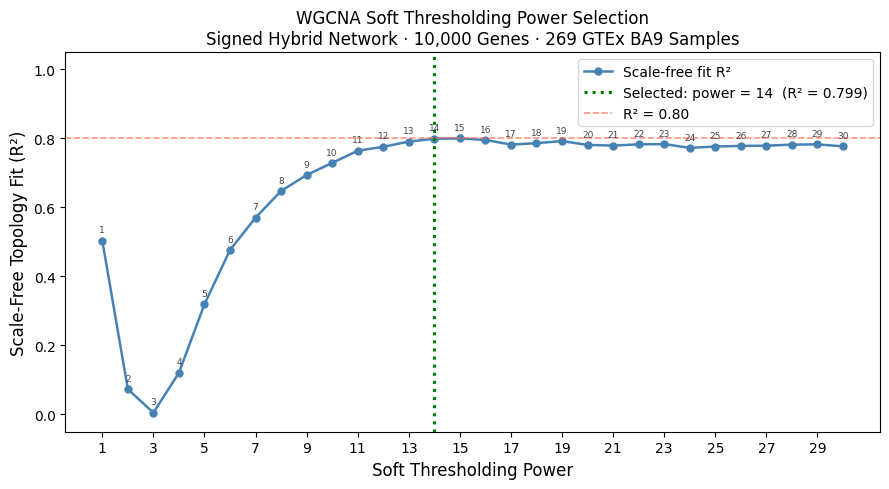

Saved: soft_threshold_plot.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

SELECTED_POWER = 14

# Load expression matrix (same 10,000-gene log2 matrix used for WGCNA)
expr_wgcna = pd.read_parquet('wgcna_expression_matrix.parquet', engine='pyarrow')
expr_T = expr_wgcna.T.astype('float64')  # samples × genes (R WGCNA convention)

ro.r('suppressPackageStartupMessages(library(WGCNA))')

with localconverter(ro.default_converter + pandas2ri.converter):
    r_datExpr = ro.conversion.py2rpy(expr_T)
ro.globalenv['datExpr'] = r_datExpr

# Run pickSoftThreshold for powers 1–30 (~5 min on 10k genes)
print("Running pickSoftThreshold for powers 1–30 (signed hybrid)…")
ro.r('''
sft <- pickSoftThreshold(
    datExpr,
    powerVector = 1:30,
    networkType = "signed hybrid",
    verbose     = 0
)
''')

r2_vals = list(ro.r('sft$fitIndices$SFT.R.sq'))
powers  = list(range(1, 31))

sft_df = pd.DataFrame({'power': powers, 'r2': r2_vals})
r2_selected = sft_df.loc[sft_df['power'] == SELECTED_POWER, 'r2'].values[0]
print(f"Done.  R² at power {SELECTED_POWER}: {r2_selected:.3f}\n")
print(sft_df.to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sft_df['power'], sft_df['r2'], 'o-',
        color='steelblue', linewidth=1.8, markersize=5,
        label='Scale-free fit R²')

# Power labels above each point
for _, row in sft_df.iterrows():
    ax.annotate(str(int(row['power'])),
                xy=(row['power'], row['r2']),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=6.5, color='#444444')

# Dotted green vertical line at selected power
ax.axvline(SELECTED_POWER, color='green', linestyle=':', linewidth=2.2,
           label=f'Selected: power = {SELECTED_POWER}  (R² = {r2_selected:.3f})')

# 0.80 reference
ax.axhline(0.80, color='tomato', linestyle='--', linewidth=1.2, alpha=0.7,
           label='R² = 0.80')

ax.set_xlabel('Soft Thresholding Power', fontsize=12)
ax.set_ylabel('Scale-Free Topology Fit (R²)', fontsize=12)
ax.set_title(
    'WGCNA Soft Thresholding Power Selection\n'
    'Signed Hybrid Network · 10,000 Genes · 269 GTEx BA9 Samples',
    fontsize=12
)
ax.set_xticks(range(1, 31, 2))
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('soft_threshold_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: soft_threshold_plot.png")

Saved: step1_diagnostics_v4.json
{
  "soft_power_used": 14,
  "r2_at_power_14": 0.799,
  "network_type": "signed hybrid",
  "merge_cut_height": 0.2,
  "min_module_size": 20,
  "deep_split": 4,
  "n_modules_detected": 10,
  "module_size_distribution": {
    "turquoise": 6853,
    "grey": 1397,
    "blue": 444,
    "brown": 406,
    "yellow": 343,
    "green": 223,
    "red": 153,
    "black": 115,
    "pink": 34,
    "magenta": 32
  },
  "snhg14_module": "grey",
  "largest_module_pct": 68.53,
  "largest_module_too_dominant": true,
  "n_modules_under_100_genes": 2,
  "n_modules_over_500_genes": 2
}


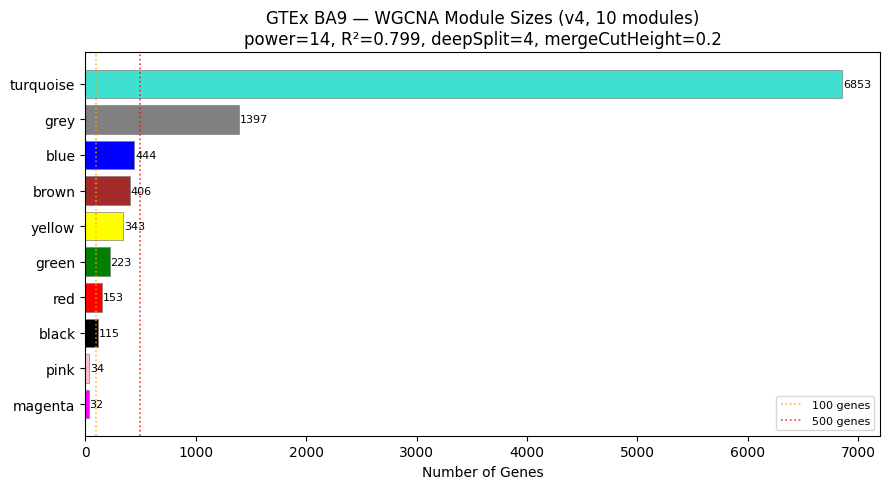

Saved: module_size_barplot_v4.png


In [6]:
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

SNHG14_ID = 'ENSG00000125968'

# ── Step 5: Diagnostics v4 ────────────────────────────────────────────────────
mod_counts = module_assignments['module_color'].value_counts()
n_total    = len(module_assignments)

largest_size  = int(mod_counts.iloc[0])
largest_pct   = round(100 * largest_size / n_total, 2)
dominant_flag = largest_pct > 50

snhg14_module = (
    str(module_assignments.loc[SNHG14_ID, 'module_color'])
    if SNHG14_ID in module_assignments.index
    else None
)

module_size_dist = {k: int(v) for k, v in mod_counts.items()}

diagnostics = {
    'soft_power_used'             : SOFT_POWER,
    'r2_at_power_14'              : 0.799,
    'network_type'                : NETWORK_TYPE,
    'merge_cut_height'            : MERGE_CUT_HEIGHT,
    'min_module_size'             : MIN_MODULE_SIZE,
    'deep_split'                  : DEEP_SPLIT,
    'n_modules_detected'          : len(mod_counts),
    'module_size_distribution'    : module_size_dist,
    'snhg14_module'               : snhg14_module,
    'largest_module_pct'          : largest_pct,
    'largest_module_too_dominant' : dominant_flag,
    'n_modules_under_100_genes'   : int((mod_counts < 100).sum()),
    'n_modules_over_500_genes'    : int((mod_counts > 500).sum()),
}

if dominant_flag:
    print(f"WARNING: largest module = {largest_pct:.1f}% of genes — "
          f"consider lower mergeCutHeight or checking network connectivity.")

with open('step1_diagnostics_v4.json', 'w') as f:
    json.dump(diagnostics, f, indent=2)
print("Saved: step1_diagnostics_v4.json")
print(json.dumps(diagnostics, indent=2))

# ── Module size barplot v4 — horizontal, sorted ascending (largest at top) ────
def safe_color(c):
    try:
        mcolors.to_rgba(c)
        return c
    except ValueError:
        return '#888888'

plot_series = mod_counts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, len(plot_series) * 0.45)))
ax.barh(
    plot_series.index,
    plot_series.values,
    color=[safe_color(c) for c in plot_series.index],
    edgecolor='grey',
    linewidth=0.5,
)
for i, (mod, cnt) in enumerate(zip(plot_series.index, plot_series.values)):
    ax.text(cnt + 8, i, str(cnt), va='center', fontsize=8)

ax.axvline(100, color='orange', linestyle=':', linewidth=1.2, alpha=0.8, label='100 genes')
ax.axvline(500, color='red',    linestyle=':', linewidth=1.2, alpha=0.8, label='500 genes')
ax.set_xlabel('Number of Genes')
ax.set_title(
    f'GTEx BA9 — WGCNA Module Sizes (v4, {len(plot_series)} modules)\n'
    f'power={SOFT_POWER}, R²=0.799, deepSplit={DEEP_SPLIT}, mergeCutHeight={MERGE_CUT_HEIGHT}'
)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('module_size_barplot_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: module_size_barplot_v4.png")

## Step 2: Fisher's Exact Test — NSC Gene Enrichment in WGCNA Modules

In [7]:
import pandas as pd

# Load WGCNA module assignments from Step 1
modules = pd.read_csv('wgcna_module_assignments.csv')
print(f"WGCNA module assignments: {len(modules):,} genes  |  {modules['module_color'].nunique()} modules")
print(modules['module_color'].value_counts().to_dict())

# NSC query set: genes with selection_frequency == 1.0
nsc_genes = pd.read_csv('data/nsc_genes_t1_0.csv')
nsc_query = (
    nsc_genes[nsc_genes['selection_frequency'] == 1.0][['gene_id']]
    .copy()
    .reset_index(drop=True)
)
print(f"\nNSC query genes (selection_frequency == 1.0): {len(nsc_query):,}")

# Inner join to find overlap with WGCNA gene universe
wgcna_gene_set      = set(modules['gene_id'])
nsc_query_matched   = nsc_query[nsc_query['gene_id'].isin(wgcna_gene_set)].copy().reset_index(drop=True)
nsc_query_unmatched = nsc_query[~nsc_query['gene_id'].isin(wgcna_gene_set)].copy().reset_index(drop=True)

print(f"\nNSC genes matched in WGCNA:  {len(nsc_query_matched):,}")
print(f"NSC genes unmatched:         {len(nsc_query_unmatched):,}")
if len(nsc_query_unmatched):
    print(f"Unmatched gene IDs: {nsc_query_unmatched['gene_id'].tolist()}")

WGCNA module assignments: 10,000 genes  |  10 modules
{'turquoise': 6853, 'grey': 1397, 'blue': 444, 'brown': 406, 'yellow': 343, 'green': 223, 'red': 153, 'black': 115, 'pink': 34, 'magenta': 32}

NSC query genes (selection_frequency == 1.0): 392

NSC genes matched in WGCNA:  368
NSC genes unmatched:         24
Unmatched gene IDs: ['ENSG00000055732', 'ENSG00000109805', 'ENSG00000114248', 'ENSG00000132446', 'ENSG00000137860', 'ENSG00000138180', 'ENSG00000139618', 'ENSG00000139865', 'ENSG00000148773', 'ENSG00000165164', 'ENSG00000177669', 'ENSG00000181544', 'ENSG00000181626', 'ENSG00000188817', 'ENSG00000197757', 'ENSG00000221867', 'ENSG00000235718', 'ENSG00000248710', 'ENSG00000251201', 'ENSG00000253293', 'ENSG00000276368', 'ENSG00000281131', 'ENSG00000283701', 'ENSG00000289746']


In [8]:
from scipy.stats import fisher_exact

n_background = len(modules)
query_set = set(nsc_query_matched['gene_id'])
n_query = len(query_set)

results = []
for module_color, group in modules.groupby('module_color'):
    module_genes = set(group['gene_id'])
    module_size  = len(module_genes)
    overlap      = module_genes & query_set
    n_overlap    = len(overlap)

    # 2x2 contingency table (alternative='greater' tests over-representation)
    table = [
        [n_overlap,             module_size - n_overlap],
        [n_query - n_overlap,   n_background - module_size - (n_query - n_overlap)],
    ]
    _, pvalue = fisher_exact(table, alternative='greater')

    expected       = module_size * (n_query / n_background)
    fold_enrichment = (n_overlap / module_size) / (n_query / n_background) if n_query > 0 else 0.0

    results.append({
        'module_color'         : module_color,
        'module_size'          : module_size,
        'n_nsc_genes_in_module': n_overlap,
        'expected_overlap'     : round(expected, 4),
        'fold_enrichment'      : round(fold_enrichment, 4),
        'pvalue'               : pvalue,
        'nsc_genes_in_module'  : ';'.join(sorted(overlap)),
    })

enrichment_df = pd.DataFrame(results).sort_values('pvalue').reset_index(drop=True)
print(f"Background: {n_background:,} genes  |  Query: {n_query:,} matched NSC genes\n")
print(enrichment_df[[
    'module_color', 'module_size', 'n_nsc_genes_in_module',
    'expected_overlap', 'fold_enrichment', 'pvalue'
]].to_string(index=False))

Background: 10,000 genes  |  Query: 368 matched NSC genes

module_color  module_size  n_nsc_genes_in_module  expected_overlap  fold_enrichment       pvalue
       black          115                     21            4.2320           4.9622 9.585631e-10
        blue          444                     41           16.3392           2.5093 4.280940e-08
       brown          406                     14           14.9408           0.9370 6.385010e-01
       green          223                      7            8.2064           0.8530 7.188422e-01
        pink           34                      1            1.2512           0.7992 7.211137e-01
         red          153                      4            5.6304           0.7104 8.200193e-01
   turquoise         6853                    237          252.1904           0.9398 9.625735e-01
        grey         1397                     38           51.4096           0.7392 9.861411e-01
      yellow          343                      5           12.6224  

In [9]:
from statsmodels.stats.multitest import multipletests

_, fdr_values, _, _ = multipletests(enrichment_df['pvalue'], method='fdr_bh')
enrichment_df['fdr'] = fdr_values
enrichment_df['significant'] = fdr_values < 0.05

print("BH-FDR correction applied.\n")
print(enrichment_df[[
    'module_color', 'module_size', 'n_nsc_genes_in_module',
    'fold_enrichment', 'pvalue', 'fdr', 'significant'
]].to_string(index=False))
print(f"\nSignificant modules (FDR < 0.05): {enrichment_df['significant'].sum()}")

BH-FDR correction applied.

module_color  module_size  n_nsc_genes_in_module  fold_enrichment       pvalue          fdr  significant
       black          115                     21           4.9622 9.585631e-10 9.585631e-09         True
        blue          444                     41           2.5093 4.280940e-08 2.140470e-07         True
       brown          406                     14           0.9370 6.385010e-01 1.000000e+00        False
       green          223                      7           0.8530 7.188422e-01 1.000000e+00        False
        pink           34                      1           0.7992 7.211137e-01 1.000000e+00        False
         red          153                      4           0.7104 8.200193e-01 1.000000e+00        False
   turquoise         6853                    237           0.9398 9.625735e-01 1.000000e+00        False
        grey         1397                     38           0.7392 9.861411e-01 1.000000e+00        False
      yellow          343  

In [10]:
enrichment_df[[
    'module_color', 'module_size', 'n_nsc_genes_in_module',
    'expected_overlap', 'fold_enrichment', 'pvalue', 'fdr',
    'significant', 'nsc_genes_in_module'
]].to_csv('enrichment_results.csv', index=False)
print("Saved: enrichment_results.csv\n")
print(enrichment_df[[
    'module_color', 'module_size', 'n_nsc_genes_in_module',
    'fold_enrichment', 'pvalue', 'fdr', 'significant'
]].to_string(index=False))

Saved: enrichment_results.csv

module_color  module_size  n_nsc_genes_in_module  fold_enrichment       pvalue          fdr  significant
       black          115                     21           4.9622 9.585631e-10 9.585631e-09         True
        blue          444                     41           2.5093 4.280940e-08 2.140470e-07         True
       brown          406                     14           0.9370 6.385010e-01 1.000000e+00        False
       green          223                      7           0.8530 7.188422e-01 1.000000e+00        False
        pink           34                      1           0.7992 7.211137e-01 1.000000e+00        False
         red          153                      4           0.7104 8.200193e-01 1.000000e+00        False
   turquoise         6853                    237           0.9398 9.625735e-01 1.000000e+00        False
        grey         1397                     38           0.7392 9.861411e-01 1.000000e+00        False
      yellow          34

Saved: step2_diagnostics.json
{
  "n_nsc_genes_query": 392,
  "n_nsc_genes_matched_to_wgcna": 368,
  "n_unmatched_nsc_genes": [
    "ENSG00000055732",
    "ENSG00000109805",
    "ENSG00000114248",
    "ENSG00000132446",
    "ENSG00000137860",
    "ENSG00000138180",
    "ENSG00000139618",
    "ENSG00000139865",
    "ENSG00000148773",
    "ENSG00000165164",
    "ENSG00000177669",
    "ENSG00000181544",
    "ENSG00000181626",
    "ENSG00000188817",
    "ENSG00000197757",
    "ENSG00000221867",
    "ENSG00000235718",
    "ENSG00000248710",
    "ENSG00000251201",
    "ENSG00000253293",
    "ENSG00000276368",
    "ENSG00000281131",
    "ENSG00000283701",
    "ENSG00000289746"
  ],
  "n_modules_tested": 10,
  "n_significant_modules": 2,
  "significant_modules": [
    {
      "module_color": "black",
      "fold_enrichment": 4.9622,
      "fdr": 9.585631093147914e-09,
      "n_overlap": 21,
      "gene_list": [
        "ENSG00000065243",
        "ENSG00000068784",
        "ENSG00000079482",
  

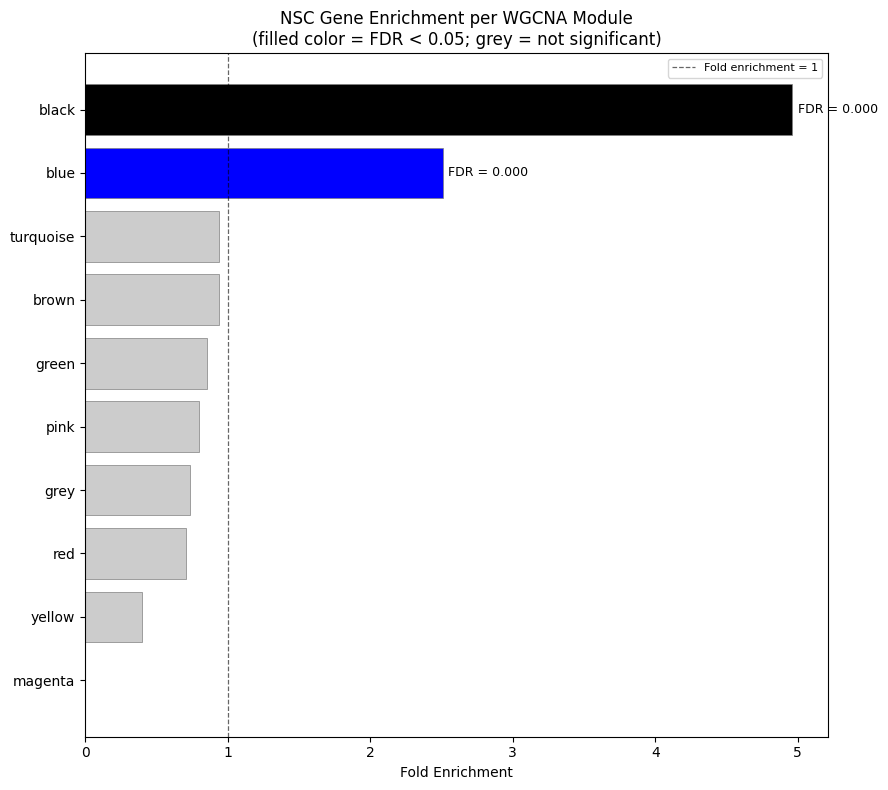

Saved: enrichment_barplot.png


In [11]:
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

SNHG14_MODULE = 'gainsboro'  # from step1_diagnostics.json

sig_modules = enrichment_df[enrichment_df['significant']].copy()
snhg14_module_enriched = bool(SNHG14_MODULE in sig_modules['module_color'].values)

significant_modules_list = [
    {
        'module_color'   : row['module_color'],
        'fold_enrichment': float(row['fold_enrichment']),
        'fdr'            : float(row['fdr']),
        'n_overlap'      : int(row['n_nsc_genes_in_module']),
        'gene_list'      : row['nsc_genes_in_module'].split(';') if row['nsc_genes_in_module'] else []
    }
    for _, row in sig_modules.iterrows()
]

diag = {
    'n_nsc_genes_query'            : int(len(nsc_query)),
    'n_nsc_genes_matched_to_wgcna' : int(len(nsc_query_matched)),
    'n_unmatched_nsc_genes'        : nsc_query_unmatched['gene_id'].tolist(),
    'n_modules_tested'             : int(len(enrichment_df)),
    'n_significant_modules'        : int(enrichment_df['significant'].sum()),
    'significant_modules'          : significant_modules_list,
    'snhg14_module_enriched'       : snhg14_module_enriched,
}

with open('step2_diagnostics.json', 'w') as f:
    json.dump(diag, f, indent=2)
print("Saved: step2_diagnostics.json")
print(json.dumps(diag, indent=2))

# ── Enrichment barplot ────────────────────────────────────────────────────────
def _bar_color(module_color, is_sig):
    if not is_sig:
        return '#cccccc'
    try:
        mcolors.to_rgba(module_color)
        return module_color
    except ValueError:
        return '#888888'

plot_df = enrichment_df.sort_values('fold_enrichment', ascending=True).reset_index(drop=True)
bar_colors = [_bar_color(r['module_color'], r['significant']) for _, r in plot_df.iterrows()]

fig, ax = plt.subplots(figsize=(9, max(4, len(plot_df) * 0.8)))
ax.barh(plot_df['module_color'], plot_df['fold_enrichment'], color=bar_colors, edgecolor='grey', linewidth=0.5)

for i, (_, row) in enumerate(plot_df.iterrows()):
    if row['significant']:
        ax.text(row['fold_enrichment'] + 0.04, i, f"FDR = {row['fdr']:.3f}", va='center', fontsize=9)

ax.axvline(1.0, color='black', linestyle='--', linewidth=0.9, alpha=0.6, label='Fold enrichment = 1')
ax.set_xlabel('Fold Enrichment')
ax.set_title('NSC Gene Enrichment per WGCNA Module\n(filled color = FDR < 0.05; grey = not significant)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('enrichment_barplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: enrichment_barplot.png")

## Step 3: Module Functional Enrichment — GO Biological Process + KEGG Pathways

Black module (115 genes) and blue module (444 genes) enriched against the full 10,000-gene WGCNA background using the gProfiler API.

In [12]:
import pandas as pd
import json
from gprofiler import GProfiler

# ── Load module assignments ───────────────────────────────────────────────────
modules = pd.read_csv('wgcna_module_assignments.csv')
background_genes = modules['gene_id'].tolist()

black_genes = modules.loc[modules['module_color'] == 'black', 'gene_id'].tolist()
blue_genes  = modules.loc[modules['module_color'] == 'blue',  'gene_id'].tolist()

print(f"Black module: {len(black_genes):,} genes")
print(f"Blue module:  {len(blue_genes):,} genes")
print(f"Background:   {len(background_genes):,} WGCNA genes (blue only; black uses full genome)\n")

gp = GProfiler(return_dataframe=True)

# ── Convert Ensembl IDs → gene symbols via g:Convert ─────────────────────────
def ensembl_to_symbol_map(gene_ids):
    conv = gp.convert(query=gene_ids, organism='hsapiens',
                      target_namespace='ENTREZGENE_ACC')
    return dict(zip(conv['incoming'], conv['name']))

print("Converting Ensembl IDs → gene symbols...")
black_symbol_map = ensembl_to_symbol_map(black_genes)
blue_symbol_map  = ensembl_to_symbol_map(blue_genes)
print(f"  Black: {sum(1 for v in black_symbol_map.values() if v)} symbols resolved")
print(f"  Blue:  {sum(1 for v in blue_symbol_map.values() if v)} symbols resolved")

print("\nBlack gene symbol examples:")
for eid, sym in list(black_symbol_map.items())[:8]:
    print(f"  {eid} → {sym}")

# ── Run GO:BP + KEGG enrichment via gProfiler API ────────────────────────────
def run_enrichment(gene_ids, background, label):
    bg_desc = "full genome" if background is None else f"{len(background):,}-gene WGCNA universe"
    print(f"\nRunning enrichment — {label} module ({len(gene_ids)} genes, background: {bg_desc})...")
    results = gp.profile(
        query=gene_ids,
        organism='hsapiens',
        sources=['GO:BP', 'KEGG'],
        background=background,
        significance_threshold_method='fdr',
        user_threshold=0.05,
        no_evidences=False,
    )
    if 'source' not in results.columns:
        print(f"  No results (empty response)")
        return results
    n_gobp = (results['source'] == 'GO:BP').sum()
    n_kegg = (results['source'] == 'KEGG').sum()
    print(f"  Significant terms: {n_gobp} GO:BP, {n_kegg} KEGG")
    return results

black_results = run_enrichment(black_genes, None,             'black')  # full genome background
blue_results  = run_enrichment(blue_genes,  background_genes, 'blue')   # WGCNA background

# ── Detect column names (changed between gprofiler-official versions) ──────────
# Derive from the full results DataFrames — top-N slices may be empty
_ref = next((r for r in [black_results, blue_results] if len(r.columns)), black_results)
_name_col = 'term_name' if 'term_name' in _ref.columns else 'name'
_id_col   = 'term_id'   if 'term_id'   in _ref.columns else 'native'
_want = ['source', _id_col, _name_col, 'p_value', 'term_size',
         'query_size', 'intersection_size', 'precision', 'recall', 'intersections']
_keep = [c for c in _want if c in _ref.columns]

# ── Top 10 per source — always concat to preserve column structure ─────────────
def top10_per_source(df):
    if 'source' not in df.columns:
        return df
    frames = [df[df['source'] == src].sort_values('p_value').head(10).copy()
              for src in ['GO:BP', 'KEGG']]
    return pd.concat(frames, ignore_index=True)

black_top = top10_per_source(black_results)
blue_top  = top10_per_source(blue_results)

# reindex instead of [] — writes a header-only CSV for empty modules instead of raising
black_top.reindex(columns=_keep).to_csv('black_module_enrichment.csv', index=False)
blue_top.reindex(columns=_keep).to_csv('blue_module_enrichment.csv', index=False)
print("\nSaved: black_module_enrichment.csv")
print("Saved: blue_module_enrichment.csv")

# ── Preview ───────────────────────────────────────────────────────────────────
for label, df in [('BLACK', black_top), ('BLUE', blue_top)]:
    print(f"\n── {label} module top terms ─────────────────────────────────────────")
    disp = [c for c in ['source', _id_col, _name_col, 'p_value', 'intersection_size']
            if c in df.columns]
    if len(df) and disp:
        print(df[disp].to_string(index=False))
    else:
        print("  (no significant terms at FDR < 0.05)")

# ── Summary ───────────────────────────────────────────────────────────────────
def top_term(df, source):
    if 'source' not in df.columns or len(df) == 0:
        return 'none significant', None
    sub = df[df['source'] == source].sort_values('p_value')
    if len(sub) == 0:
        return 'none significant', None
    row = sub.iloc[0]
    return f"{row[_name_col]} ({row[_id_col]})", float(row['p_value'])

summary = {}
for mod, df in [('black', black_top), ('blue', blue_top)]:
    gobp_label, gobp_p = top_term(df, 'GO:BP')
    kegg_label, kegg_p = top_term(df, 'KEGG')
    summary[mod] = {
        'top_GO_BP'      : gobp_label,
        'top_GO_BP_padj' : gobp_p,
        'top_KEGG'       : kegg_label,
        'top_KEGG_padj'  : kegg_p,
    }

with open('module_enrichment_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n── Enrichment Summary ─────────────────────────────────────────────────────")
for mod, info in summary.items():
    print(f"\n{mod.upper()} module:")
    print(f"  Top GO:BP : {info['top_GO_BP']}")
    if info['top_GO_BP_padj'] is not None:
        print(f"              FDR = {info['top_GO_BP_padj']:.2e}")
    print(f"  Top KEGG  : {info['top_KEGG']}")
    if info['top_KEGG_padj'] is not None:
        print(f"              FDR = {info['top_KEGG_padj']:.2e}")

print("\nSaved: module_enrichment_summary.json")

Black module: 115 genes
Blue module:  444 genes
Background:   10,000 WGCNA genes (blue only; black uses full genome)

Converting Ensembl IDs → gene symbols...
  Black: 115 symbols resolved
  Blue:  444 symbols resolved

Black gene symbol examples:
  ENSG00000128585 → MKLN1
  ENSG00000147027 → TMEM47
  ENSG00000076716 → GPC4
  ENSG00000011201 → ANOS1
  ENSG00000147853 → AK3
  ENSG00000011405 → PIK3C2A
  ENSG00000092969 → TGFB2
  ENSG00000067141 → NEO1

Running enrichment — black module (115 genes, background: full genome)...
  Significant terms: 396 GO:BP, 0 KEGG

Running enrichment — blue module (444 genes, background: 10,000-gene WGCNA universe)...
  Significant terms: 0 GO:BP, 0 KEGG

Saved: black_module_enrichment.csv
Saved: blue_module_enrichment.csv

── BLACK module top terms ─────────────────────────────────────────
source     native                               name      p_value  intersection_size
 GO:BP GO:0007155                      cell adhesion 1.371548e-07                

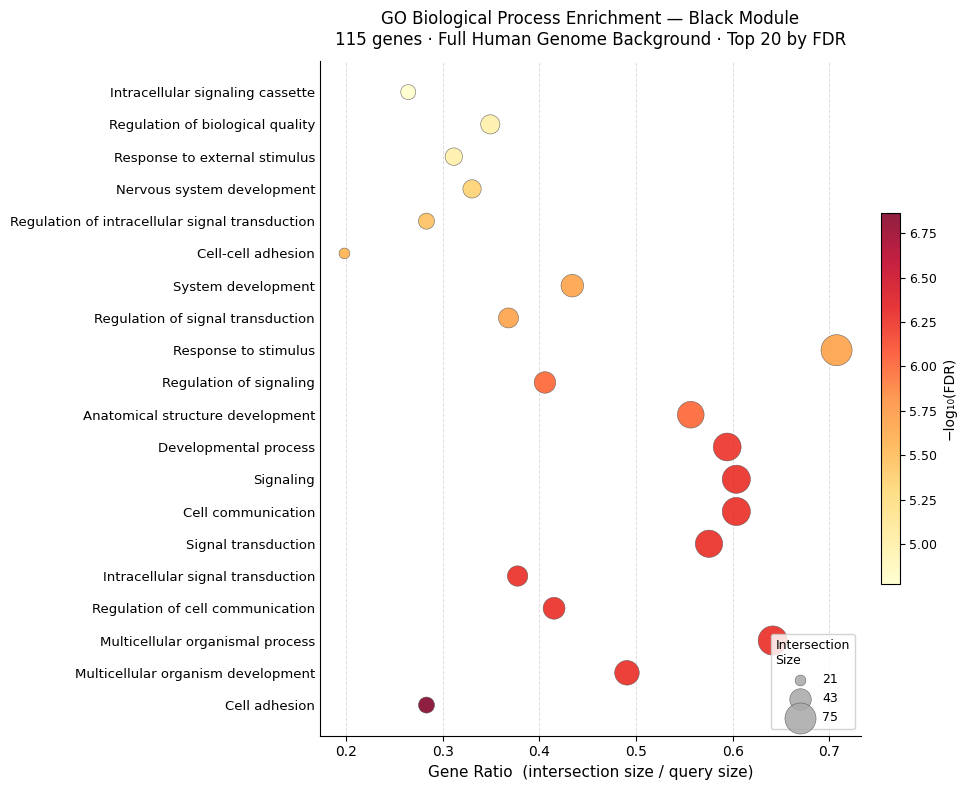

Saved: black_module_gobp_dotplot.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

TOP_N      = 20
NAME_COL   = 'name'    if 'name'    in black_results.columns else 'term_name'
QUERY_SIZE = black_results['query_size'].iloc[0] if len(black_results) else 115

# ── Prepare data ──────────────────────────────────────────────────────────────
gobp = (
    black_results[black_results['source'] == 'GO:BP']
    .sort_values('p_value')
    .head(TOP_N)
    .copy()
)

gobp['gene_ratio']    = gobp['intersection_size'] / QUERY_SIZE
gobp['neg_log10_fdr'] = -np.log10(gobp['p_value'])
gobp['label']         = gobp[NAME_COL].str.replace('_', ' ').str.capitalize().str[:52]

# Sort ascending p-value so most significant sits at the top of the vertical axis
gobp = gobp.sort_values('p_value', ascending=True).reset_index(drop=True)
y_pos = np.arange(len(gobp))

# ── Dot sizes scaled to intersection_size ─────────────────────────────────────
s_min, s_max = 60, 500
s_range = gobp['intersection_size'].max() - gobp['intersection_size'].min()
dot_sizes = (
    s_min + (gobp['intersection_size'] - gobp['intersection_size'].min())
    / max(s_range, 1) * (s_max - s_min)
)

# ── Color mapped to −log10(FDR): warmer = more significant ───────────────────
cmap = plt.cm.YlOrRd
norm = mcolors.Normalize(
    vmin=gobp['neg_log10_fdr'].min(),
    vmax=gobp['neg_log10_fdr'].max(),
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    gobp['gene_ratio'],
    y_pos,
    c=gobp['neg_log10_fdr'],
    s=dot_sizes,
    cmap=cmap,
    norm=norm,
    alpha=0.88,
    edgecolors='#555555',
    linewidths=0.4,
    zorder=3,
)

# Light horizontal grid behind dots
ax.set_yticks(y_pos)
ax.set_yticklabels(gobp['label'], fontsize=9.5)
ax.yaxis.set_tick_params(length=0)
ax.set_axisbelow(True)
ax.grid(axis='x', color='#dddddd', linewidth=0.7, linestyle='--')

ax.set_xlabel('Gene Ratio  (intersection size / query size)', fontsize=11)
ax.set_title(
    'GO Biological Process Enrichment — Black Module\n'
    f'115 genes · Full Human Genome Background · Top {TOP_N} by FDR',
    fontsize=12, pad=12,
)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.03)
cbar.set_label('−log₁₀(FDR)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ── Size legend ───────────────────────────────────────────────────────────────
legend_sizes = sorted({
    int(gobp['intersection_size'].min()),
    int(gobp['intersection_size'].median()),
    int(gobp['intersection_size'].max()),
})
for lv in legend_sizes:
    scaled = s_min + (lv - gobp['intersection_size'].min()) / max(s_range, 1) * (s_max - s_min)
    ax.scatter([], [], s=scaled, c='#aaaaaa', edgecolors='#555555',
               linewidths=0.4, alpha=0.88, label=f'{lv}')
ax.legend(
    title='Intersection\nSize', title_fontsize=9,
    fontsize=9, loc='lower right', framealpha=0.85,
)

ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('black_module_gobp_dotplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: black_module_gobp_dotplot.png")